In [27]:
from pathlib import Path
import random
import shutil
import yaml

# Paths
root = Path("dataset/bear_v1")
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"
valid_images = root / "valid" / "images"
valid_labels = root / "valid" / "labels"

# Ensure validation folders exist
valid_images.mkdir(parents=True, exist_ok=True)
valid_labels.mkdir(parents=True, exist_ok=True)

# Build a validation split only if valid/images is currently empty
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
train_imgs = sorted([p for p in train_images.iterdir() if p.suffix.lower() in image_exts])
valid_imgs = sorted([p for p in valid_images.iterdir() if p.suffix.lower() in image_exts])

if len(valid_imgs) == 0 and len(train_imgs) > 1:
    random.seed(42)
    split_ratio = 0.2
    n_val = max(1, int(len(train_imgs) * split_ratio))
    val_set = set(random.sample(train_imgs, n_val))

    for img_path in val_set:
        label_src = train_labels / f"{img_path.stem}.txt"
        shutil.move(str(img_path), str(valid_images / img_path.name))
        if label_src.exists():
            shutil.move(str(label_src), str(valid_labels / label_src.name))

# Recount after potential split
train_count = len([p for p in train_images.iterdir() if p.suffix.lower() in image_exts])
valid_count = len([p for p in valid_images.iterdir() if p.suffix.lower() in image_exts])
print(f"Train images: {train_count}")
print(f"Valid images: {valid_count}")

# Generate a clean YOLO data config
src_yaml = root / "data.yaml"
fixed_yaml = root / "data_fixed.yaml"

names = ["bear"]
nc = 1
if src_yaml.exists():
    with src_yaml.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
    names = cfg.get("names", names)
    nc = int(cfg.get("nc", len(names)))

fixed_cfg = {
    "train": str((root / "train" / "images").resolve()),
    "val": str((root / "valid" / "images").resolve()),
    "nc": nc,
    "names": names,
}

with fixed_yaml.open("w", encoding="utf-8") as f:
    yaml.safe_dump(fixed_cfg, f, sort_keys=False)

print(f"Wrote: {fixed_yaml}")
print(fixed_cfg)

Train images: 24
Valid images: 6
Wrote: dataset/bear_v1/data_fixed.yaml
{'train': '/ros2_ws/yolo_train/dataset/bear_v1/train/images', 'val': '/ros2_ws/yolo_train/dataset/bear_v1/valid/images', 'nc': 1, 'names': ['0']}


In [28]:
from ultralytics import YOLO
import torch
from pathlib import Path

# train an yolo v8 with data augmentation
data_yaml = Path("dataset/bear_v1/data_fixed.yaml")
assert data_yaml.exists(), f"Missing {data_yaml}, run previous cell first."

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on device:", device)

model = YOLO("yolov8n.pt")
train_results = model.train(
    data=str(data_yaml),
    epochs=2000,
    batch=24,
    imgsz=640,
    lr0=0.005,
    lrf=0.1,
    name="yolo_bear_aug",
    augment=True,
    device=device,
)

# save_dir comes from the trainer and is stable for later cells
results_dir = Path(model.trainer.save_dir)
print(f"Training run dir: {results_dir}")

Running on device: cuda
Ultralytics 8.4.41 🚀 Python-3.10.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/bear_v1/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2000, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_bear_aug-6, nbs=64, nms=False, opset=None, optimize=False,

Best model path: /ros2_ws/yolo_train/runs/detect/yolo_bear_aug-6/weights/best.pt
Running inference on: dataset/bear_v1/valid/images/car_image_20260424_030910_501000_jpg.rf.wteLGQpgzCY9Gz04vFXF.jpg

image 1/1 /ros2_ws/yolo_train/dataset/bear_v1/valid/images/car_image_20260424_030910_501000_jpg.rf.wteLGQpgzCY9Gz04vFXF.jpg: 480x640 1 0, 2.1ms
Speed: 0.5ms preprocess, 2.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)


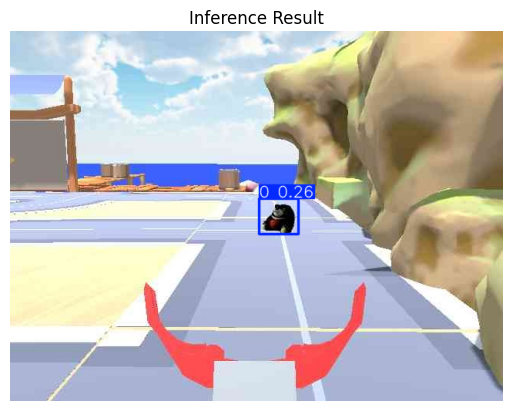

In [29]:
# show results
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from ultralytics import YOLO
import numpy as np

# set matplotlib to inline if in a notebook environment
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

# Prefer run directory from current session; fallback to latest matching run on disk.
if "results_dir" in globals():
    run_dir = Path(results_dir)
else:
    run_candidates = sorted(
        Path("runs/detect").glob("yolo_bear_aug*"),
        key=lambda p: p.stat().st_mtime,
    )
    if not run_candidates:
        raise FileNotFoundError("No YOLO training run found. Run Cell 2 first.")
    run_dir = run_candidates[-1]

best_weights = run_dir / "weights" / "best.pt"
print(f"Best model path: {best_weights}")

if best_weights.exists():
    best_model = YOLO(str(best_weights))
    val_images = sorted([
        p for p in (data_yaml.parent / "valid" / "images").iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    ])
    if val_images:
        img_path = val_images[np.random.randint(len(val_images))]
        print(f"Running inference on: {img_path}")
        pred_results = best_model(str(img_path))
        result_img = pred_results[0].plot()
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Inference Result")
        plt.show()
    else:
        print("No validation images found for inference.")
else:
    print("best.pt not found yet. Wait for training to finish.")